# Day 2 — Conv2d and pooling

Use PyTorch `Conv2d` and `MaxPool2d` to connect manual filters to CNN layers.

Official docs:

- [`torch.nn.Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [`torch.nn.MaxPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)


## Shape convention: `[batch, channels, height, width]`

PyTorch convolution layers expect image-like tensors in this order:

```text
[batch, channels, height, width]
```

For example, a tensor with shape `torch.Size([1, 1, 8, 8])` means:

- `batch = 1`: one image is being processed.
- `channels = 1`: the image has one value grid, so it is grayscale.
- `height = 8`: the image is 8 pixels tall.
- `width = 8`: the image is 8 pixels wide.

This shape habit matters because `Conv2d` needs its `in_channels` value to match the input image's channel count.


image_batch shape: torch.Size([1, 1, 256, 256])


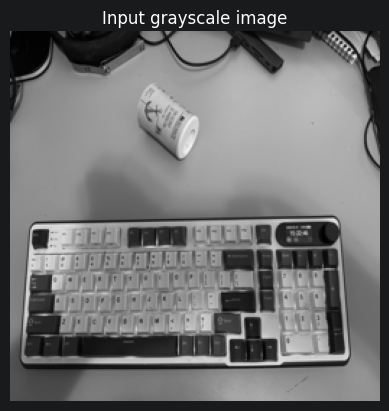

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch import nn

image_path = Path("../data/my_sample_image.jpg")
output_dir = Path("../outputs/day02_conv2d_pooling")
output_dir.mkdir(parents=True, exist_ok=True)

gray_image = Image.open(image_path).convert("L").resize((256, 256))
gray_array = np.array(gray_image, dtype=np.float32) / 255.0

# PyTorch Conv2d expects BCHW: [batch, channels, height, width].
image_batch = torch.from_numpy(gray_array).unsqueeze(0).unsqueeze(0)

print("image_batch shape:", image_batch.shape)

plt.imshow(image_batch[0, 0], cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("Input grayscale image")
plt.show()


## Conv2d: producing a feature map

A `Conv2d` layer slides a small grid of numbers, called a **kernel** or **filter**, across the image. At each location, the filter produces one number that says how strongly that local patch matched the filter pattern. The full grid of those numbers is the **feature map**.

For one grayscale input and one fixed edge-detection filter, the layer setup is conceptually:

```python
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, bias=False)
```

The convolution weight tensor uses this shape:

```text
[out_channels, in_channels, kernel_height, kernel_width]
```

So `conv.weight[0, 0]` means: first output feature map, first input channel, and the 3×3 filter values for that channel.

### Why `[0, 0]`?

A `Conv2d` weight tensor is indexed in this order:

```text
[which output feature map, which input channel, kernel row, kernel column]
```

In this notebook, the input image shape is `torch.Size([1, 1, 256, 256])`. The second `1` means the image has one grayscale channel, so the layer uses `in_channels=1`.

The layer also uses `out_channels=1` because we only want to create one fixed edge-detection feature map for now. With one output feature map and one input channel, the only available kernel slot is `conv.weight[0, 0]`.

If the input image were RGB, the input would have 3 channels, so the layer would need `in_channels=3`. If the layer had `out_channels=4`, it would learn or store 4 different filters and produce 4 output feature maps.


In [4]:
conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    padding=1,
    bias=False,
)

# This filter responds strongly when brightness changes left-to-right.
edge_kernel = torch.tensor(
    [
        [-1.0, 0.0, 1.0],
        [-1.0, 0.0, 1.0],
        [-1.0, 0.0, 1.0],
    ]
)

with torch.no_grad():
    conv.weight[0, 0] = edge_kernel

feature_map = conv(image_batch)

print("conv.weight shape:", conv.weight.shape)
print("feature_map shape:", feature_map.shape)


conv.weight shape: torch.Size([1, 1, 3, 3])
feature_map shape: torch.Size([1, 1, 256, 256])


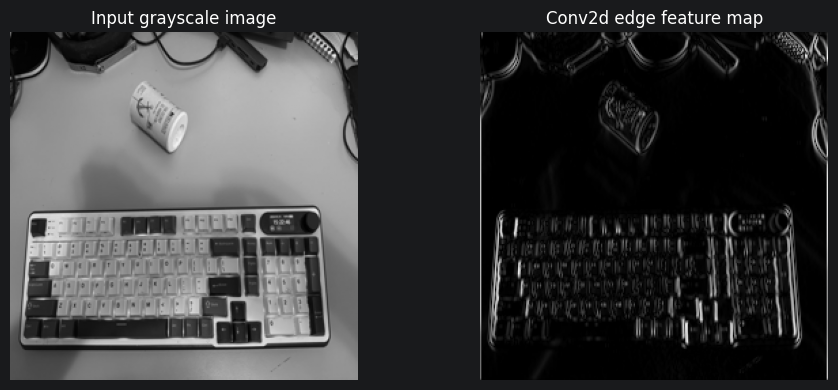

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image_batch[0, 0], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Input grayscale image")
axes[0].axis("off")

axes[1].imshow(feature_map[0, 0].detach().abs(), cmap="gray")
axes[1].set_title("Conv2d edge feature map")
axes[1].axis("off")

plt.tight_layout()
fig.savefig(output_dir / "conv2d_feature_map_grid.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)

pooled_feature_map = pool(feature_map)

print("before pooling:", feature_map.shape)
print("after pooling:", pooled_feature_map.shape)

before pooling: torch.Size([1, 1, 256, 256])
after pooling: torch.Size([1, 1, 128, 128])
